**PREDICCIÓN DE TIPO DE CAMBIO USD-JPY**


In [23]:
# Celda 1: Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Perceptron
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, f1_score, r2_score, confusion_matrix, mean_squared_error, mean_absolute_error
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


In [24]:
# Celda 2: Cargar y explorar los nuevos datos
# Cargar el archivo CSV
df = pd.read_csv('USD_JPY Historical Data Diaria.csv')

# Mostrar información básica antes de la limpieza
print("Información del dataset (antes de limpieza):")
print(df.info())
print("\nPrimeras 5 filas (antes de limpieza):")
print(df.head())

# Verificar nombres de columnas exactos
print(f"\nNombres de columnas: {df.columns.tolist()}")

# ELIMINAR LA COLUMNA DE VOLUMEN YA QUE ESTÁ VACÍA
# Identificar si existe columna de volumen
volume_col = None
for col in df.columns:
    if 'Vol' in col or 'vol' in col:
        volume_col = col
        break

if volume_col:
    print(f"\n⚠ Eliminando columna '{volume_col}' ya que no tiene datos útiles")
    df = df.drop(columns=[volume_col])

# Limpiar y preparar los datos
# Convertir fechas - el formato es mes/día/año
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Verificar si hay fechas que no se pudieron convertir
if df['Date'].isna().any():
    print(f"\n⚠ Advertencia: {df['Date'].isna().sum()} fechas no se pudieron convertir")
    # Intentar con formato día/mes/año si el primero falla
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# Limpiar columnas de precio (remover comas y convertir a float)
for col in ['Price', 'Open', 'High', 'Low']:
    # Verificar si la columna existe
    if col in df.columns:
        # Convertir a string, reemplazar comas, luego a float
        df[col] = df[col].astype(str).str.replace(',', '', regex=False).astype(float)

# Limpiar columna de cambio porcentual "Change %" o "Change"
# Primero identificar la columna correcta (puede llamarse 'Change %' o 'Change')
change_col = None
for col in df.columns:
    if 'Change' in col:
        change_col = col
        break

if change_col:
    print(f"\n✓ Procesando columna de cambios: '{change_col}'")
    
    def convert_percentage(perc_str):
        if pd.isna(perc_str):
            return 0.0
        perc_str = str(perc_str).strip()
        if perc_str == '-' or perc_str == '':
            return 0.0
        # Remover el símbolo de porcentaje
        perc_str = perc_str.replace('%', '')
        # Manejar el signo + explícitamente
        if perc_str.startswith('+'):
            perc_str = perc_str[1:]
        # Convertir a float
        try:
            return float(perc_str)
        except:
            # Si hay error, intentar limpiar más
            perc_str = perc_str.replace(',', '').strip()
            return float(perc_str) if perc_str else 0.0
    
    df['Change_Percent'] = df[change_col].apply(convert_percentage)
    # Eliminar la columna original si es diferente
    if change_col != 'Change_Percent':
        df = df.drop(columns=[change_col])
else:
    print("\n⚠ No se encontró columna de cambios porcentuales")
    df['Change_Percent'] = 0.0

# Verificar que todas las conversiones fueron exitosas
print("\n" + "="*60)
print("VERIFICACIÓN DE CONVERSIÓN DE DATOS:")
print("="*60)

print(f"\nTipos de datos después de limpieza:")
print(df.dtypes)

print(f"\nRango de fechas: {df['Date'].min()} a {df['Date'].max()}")
print(f"Total de registros: {len(df)}")
print(f"Registros con fechas nulas: {df['Date'].isna().sum()}")

print("\nPrimeras 5 filas después de limpieza:")
print(df.head())

print("\nÚltimas 5 filas después de limpieza:")
print(df.tail())

print("\nEstadísticas descriptivas de columnas numéricas:")
numeric_cols = ['Price', 'Open', 'High', 'Low', 'Change_Percent']
print(df[numeric_cols].describe())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con fechas nulas si las hay
if df['Date'].isna().any():
    print(f"\nEliminando {df['Date'].isna().sum()} filas con fechas inválidas...")
    df = df.dropna(subset=['Date'])

# Verificar que los precios están en el rango esperado
print("\nVerificación de rangos de precios:")
for col in ['Price', 'Open', 'High', 'Low']:
    if col in df.columns:
        print(f"{col}: min={df[col].min():.4f}, max={df[col].max():.4f}, mean={df[col].mean():.4f}")

print(f"\nChange_Percent: min={df['Change_Percent'].min():.2f}%, max={df['Change_Percent'].max():.2f}%, mean={df['Change_Percent'].mean():.2f}%")

# Verificar la relación lógica entre precios
print("\nVerificación de integridad de datos:")
print(f"High >= Price: {(df['High'] >= df['Price']).all()}")
print(f"Low <= Price: {(df['Low'] <= df['Price']).all()}")
print(f"Open entre Low y High: {((df['Open'] >= df['Low']) & (df['Open'] <= df['High'])).all()}")
print(f"Price entre Low y High: {((df['Price'] >= df['Low']) & (df['Price'] <= df['High'])).all()}")

# Mostrar un ejemplo de cambio porcentual para verificar
print("\nEjemplos de conversión de Change %:")
print(df[['Date', 'Price', 'Change_Percent']].head(10))

# Ordenar por fecha (asegurando orden cronológico)
df = df.sort_values('Date').reset_index(drop=True)

print("\n✅ Datos cargados y limpiados exitosamente!")
print(f"Total de registros después de limpieza: {len(df)}")
print(f"Columnas finales: {df.columns.tolist()}")

Información del dataset (antes de limpieza):
<class 'pandas.DataFrame'>
RangeIndex: 13206 entries, 0 to 13205
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      13206 non-null  str    
 1   Price     13206 non-null  float64
 2   Open      13206 non-null  float64
 3   High      13206 non-null  float64
 4   Low       13206 non-null  float64
 5   Vol.      0 non-null      float64
 6   Change %  13206 non-null  str    
dtypes: float64(5), str(2)
memory usage: 722.3 KB
None

Primeras 5 filas (antes de limpieza):
         Date   Price    Open    High     Low  Vol. Change %
0  04/02/2026  159.50  158.83  159.76  158.54   NaN    0.43%
1  04/01/2026  158.81  158.71  159.02  158.26   NaN    0.06%
2  03/31/2026  158.72  159.75  159.99  158.65   NaN   -0.63%
3  03/30/2026  159.73  159.98  160.48  159.32   NaN   -0.32%
4  03/29/2026  160.24  160.23  160.46  160.11   NaN   -0.05%

Nombres de columnas: ['Date', 'Price', 'Open',

ANÁLISIS EXPLORATORIO DE DATOS (EDA)
✅ DataFrame cargado con 13206 registros


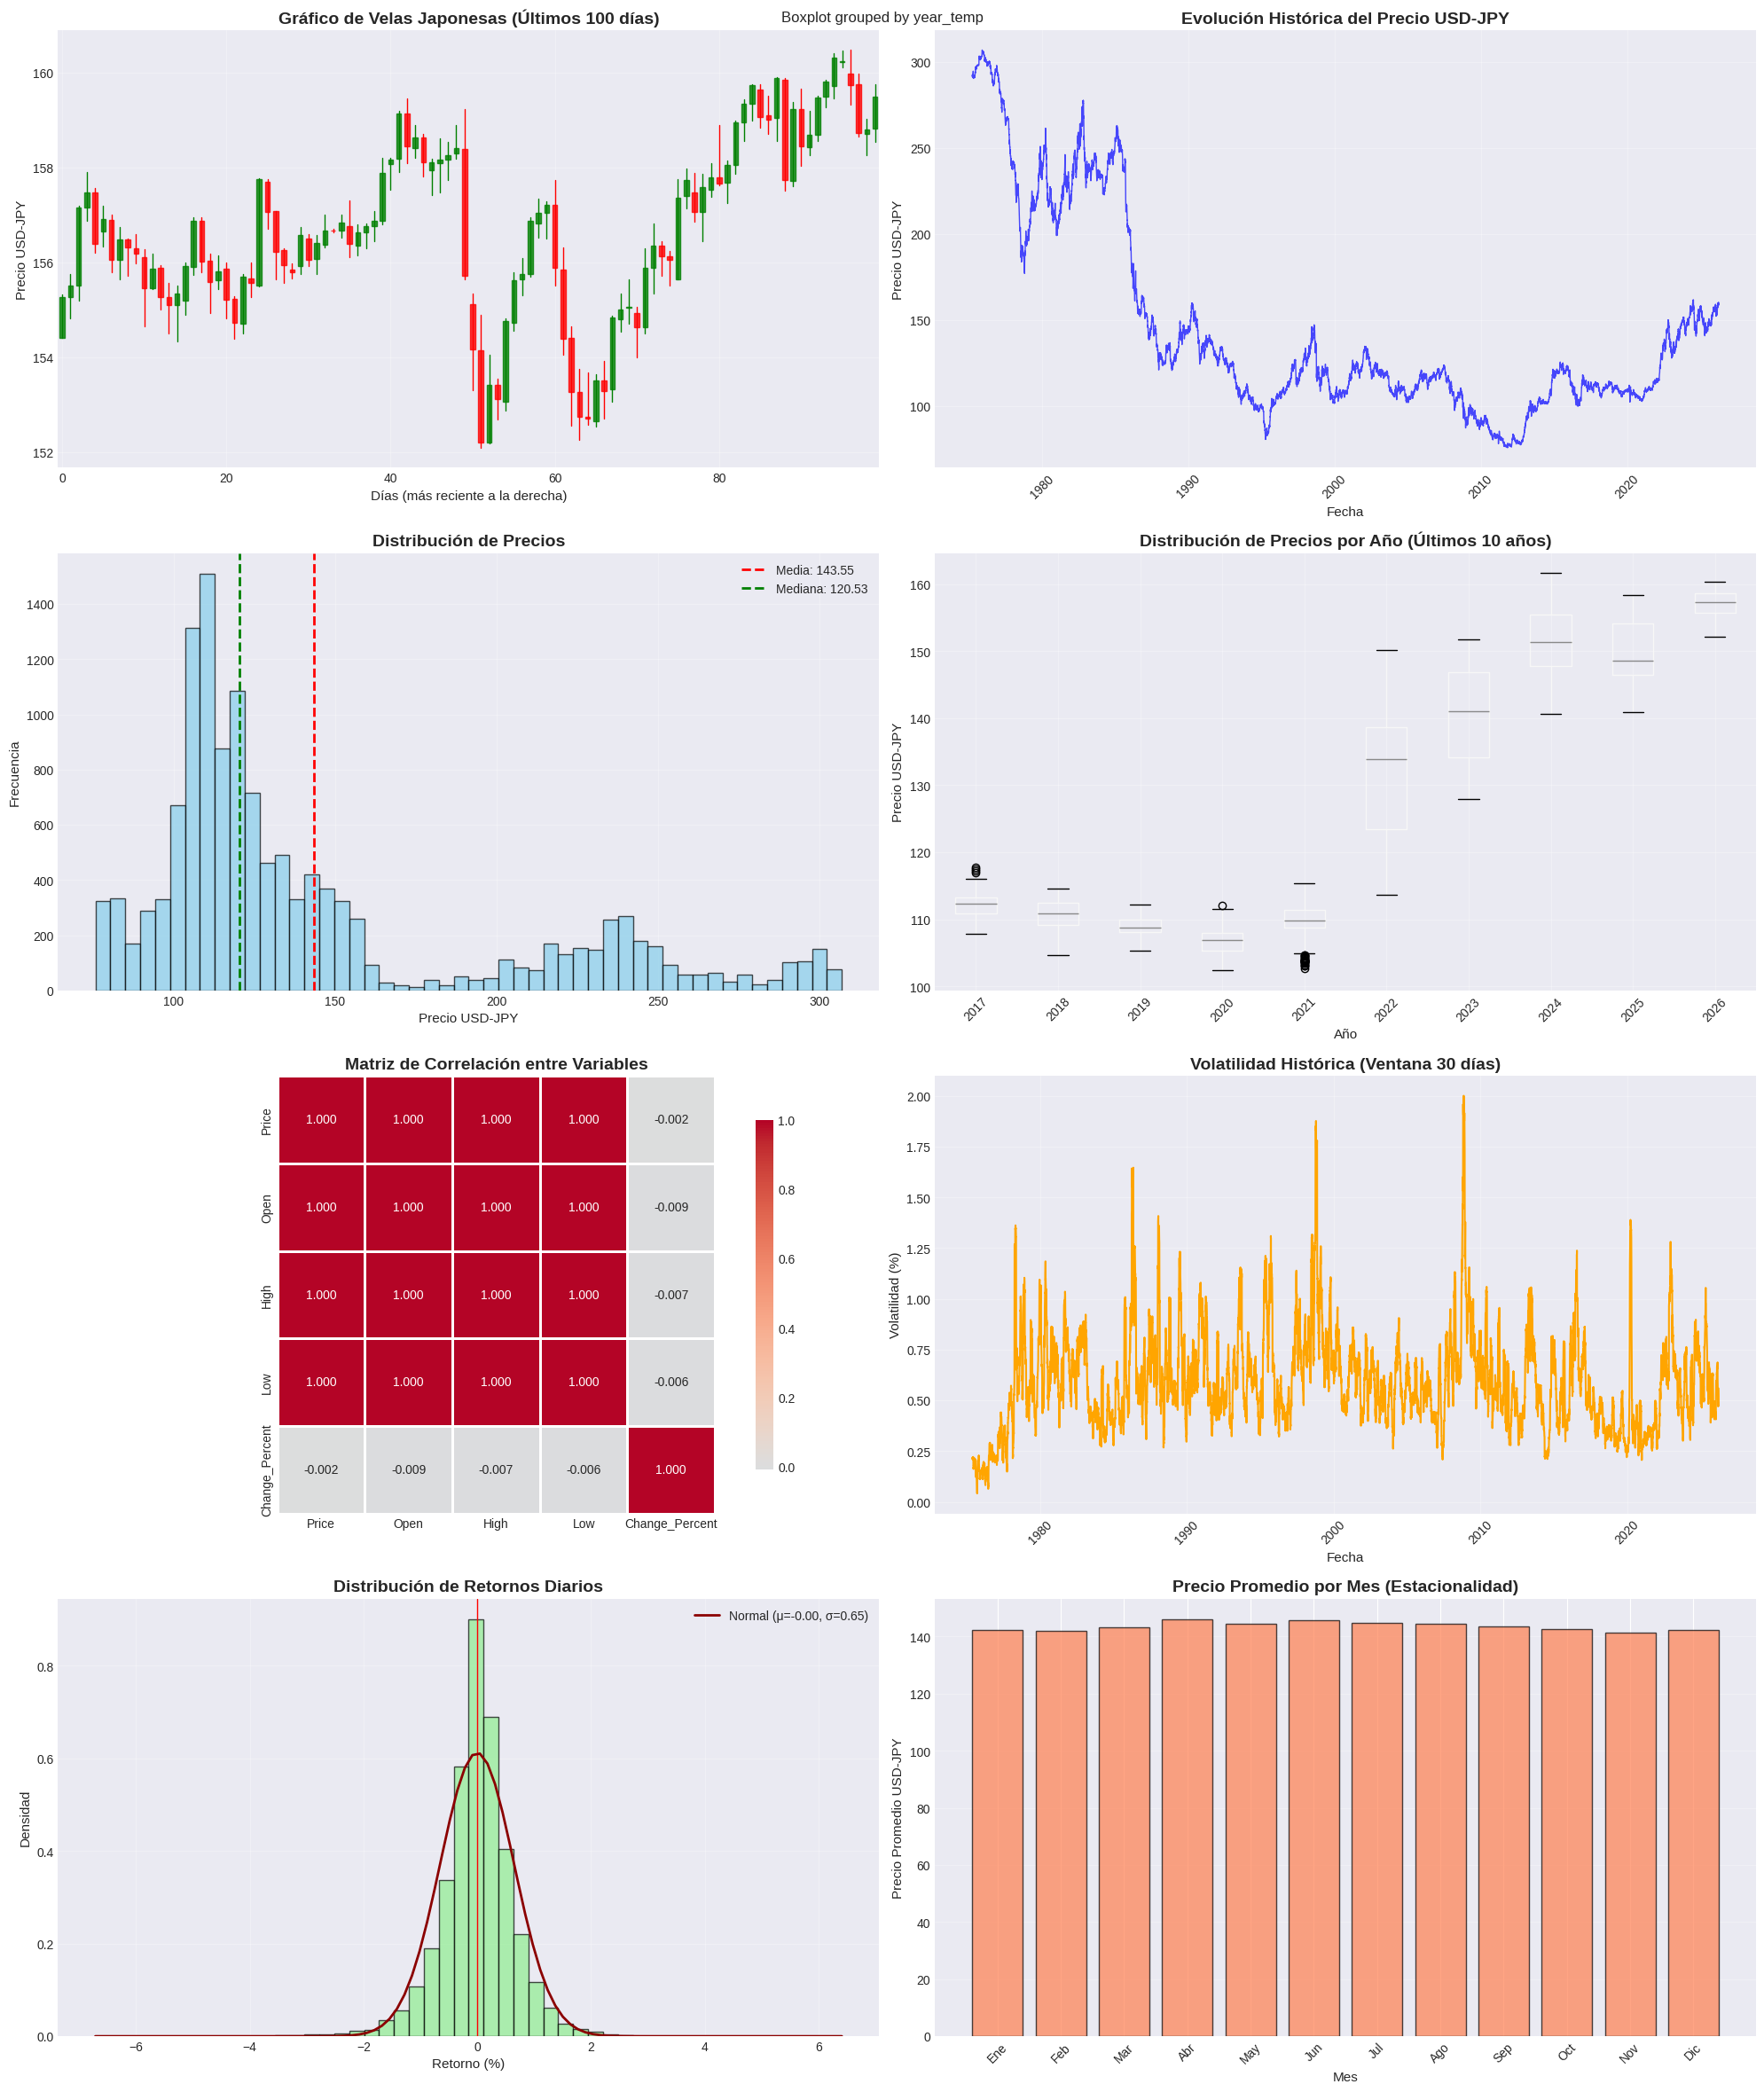


ESTADÍSTICAS DESCRIPTIVAS DETALLADAS

📊 ESTADÍSTICAS DE PRECIOS:
  Precio mínimo: 75.7900 JPY
  Precio máximo: 306.8400 JPY
  Precio medio: 143.5538 JPY
  Mediana: 120.5300 JPY
  Desviación estándar: 56.1479 JPY
  Rango intercuartil (IQR): 45.3525 JPY

📈 ESTADÍSTICAS DE RETORNOS DIARIOS:
  Retorno medio diario: -0.0024%
  Retorno mediano diario: 0.0131%
  Volatilidad diaria: 0.6520%
  Mejor día (mayor subida): 6.4123%
  Peor día (mayor bajada): -6.7164%
  Días con retorno positivo: 6686 (50.6%)
  Días con retorno negativo: 6308 (47.8%)

📅 ANÁLISIS TEMPORAL:
  Período total: 02/04/1975 - 02/04/2026
  Total de días: 13206
  Años completos: 52
  Promedio de datos por año: 254.0

📊 TENDENCIAS POR AÑO (Últimos 5 años):
  2022: 115.32 → 131.11 JPY (+13.69%)
  2023: 130.73 → 141.06 JPY (+7.90%)
  2024: 140.87 → 157.18 JPY (+11.58%)
  2025: 156.87 → 156.67 JPY (-0.13%)
  2026: 156.67 → 159.50 JPY (+1.81%)

🔗 CORRELACIONES IMPORTANTES:
  Correlación Open-Price: 1.0000
  Correlación High-Low: 0

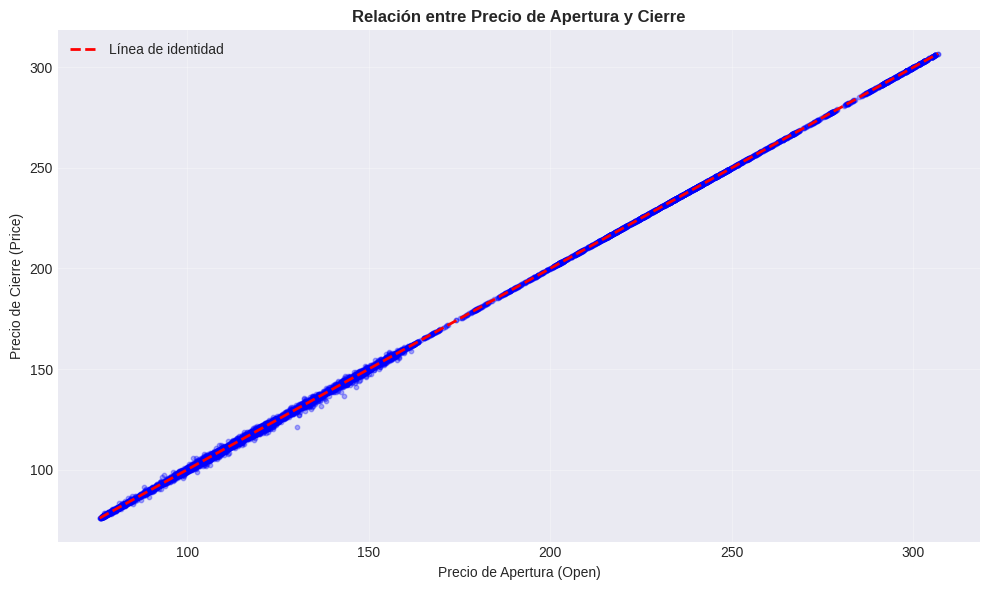


✅ Análisis Exploratorio completado. Continuando con Ingeniería de Características...


In [25]:
# Celda 3: Análisis Exploratorio de Datos (EDA)
print("=" * 80)
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("=" * 80)

# Verificar que df existe
if 'df' not in globals():
    print("ERROR: df no está definido. Asegúrate de ejecutar la Celda 2 primero.")
else:
    print(f"✅ DataFrame cargado con {len(df)} registros")
    
    # Crear figura para múltiples visualizaciones
    fig = plt.figure(figsize=(20, 24))
    
    # 1. Gráfico de Velas Japonesas (Candlestick Chart)
    ax1 = plt.subplot(4, 2, 1)
    # Tomar una muestra representativa para no saturar la gráfica (últimos 100 días)
    n_candles = min(100, len(df))
    df_candles = df.tail(n_candles).copy()
    df_candles['Date_num'] = range(len(df_candles))
    
    # Configurar colores para velas
    colors = ['green' if close >= open else 'red' for close, open in zip(df_candles['Price'], df_candles['Open'])]
    
    # Dibujar líneas verticales (wick/high-low)
    for i, (idx, row) in enumerate(df_candles.iterrows()):
        # Línea vertical desde Low hasta High
        ax1.plot([i, i], [row['Low'], row['High']], color=colors[i], linewidth=1)
        # Cuerpo de la vela (Open a Close)
        body_bottom = min(row['Open'], row['Price'])
        body_top = max(row['Open'], row['Price'])
        ax1.add_patch(plt.Rectangle((i-0.3, body_bottom), 0.6, body_top-body_bottom, 
                                    facecolor=colors[i], edgecolor=colors[i], alpha=0.8))
    
    ax1.set_title('Gráfico de Velas Japonesas (Últimos 100 días)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Días (más reciente a la derecha)', fontsize=11)
    ax1.set_ylabel('Precio USD-JPY', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.5, n_candles-0.5)
    
    # 2. Serie temporal del precio
    ax2 = plt.subplot(4, 2, 2)
    ax2.plot(df['Date'], df['Price'], color='blue', linewidth=1, alpha=0.7)
    ax2.set_title('Evolución Histórica del Precio USD-JPY', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=11)
    ax2.set_ylabel('Precio USD-JPY', fontsize=11)
    ax2.grid(True, alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    # 3. Distribución de precios (histograma)
    ax3 = plt.subplot(4, 2, 3)
    ax3.hist(df['Price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax3.axvline(df['Price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Price"].mean():.2f}')
    ax3.axvline(df['Price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["Price"].median():.2f}')
    ax3.set_title('Distribución de Precios', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Precio USD-JPY', fontsize=11)
    ax3.set_ylabel('Frecuencia', fontsize=11)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Box plot de precios por año (últimos 10 años)
    ax4 = plt.subplot(4, 2, 4)
    df['year_temp'] = df['Date'].dt.year
    recent_years = sorted(df['year_temp'].unique())[-10:]  # Últimos 10 años
    df_recent = df[df['year_temp'].isin(recent_years)]
    df_recent.boxplot(column='Price', by='year_temp', ax=ax4)
    ax4.set_title('Distribución de Precios por Año (Últimos 10 años)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Año', fontsize=11)
    ax4.set_ylabel('Precio USD-JPY', fontsize=11)
    ax4.grid(True, alpha=0.3)
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
    
    # 5. Heatmap de correlaciones
    ax5 = plt.subplot(4, 2, 5)
    correlation_cols = ['Price', 'Open', 'High', 'Low', 'Change_Percent']
    corr_matrix = df[correlation_cols].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax5)
    ax5.set_title('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold')
    
    # 6. Volatilidad histórica (rolling 30 días)
    ax6 = plt.subplot(4, 2, 6)
    df['returns_temp'] = df['Price'].pct_change() * 100
    df['volatility_temp'] = df['returns_temp'].rolling(window=30).std()
    ax6.plot(df['Date'], df['volatility_temp'], color='orange', linewidth=1.5)
    ax6.set_title('Volatilidad Histórica (Ventana 30 días)', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Fecha', fontsize=11)
    ax6.set_ylabel('Volatilidad (%)', fontsize=11)
    ax6.grid(True, alpha=0.3)
    plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45)
    
    # 7. Distribución de retornos diarios
    ax7 = plt.subplot(4, 2, 7)
    returns_clean = df['returns_temp'].dropna()
    ax7.hist(returns_clean, bins=50, color='lightgreen', edgecolor='black', alpha=0.7, density=True)
    ax7.axvline(0, color='red', linestyle='-', linewidth=1)
    # Ajustar curva normal para comparación
    mu, std = returns_clean.mean(), returns_clean.std()
    x = np.linspace(returns_clean.min(), returns_clean.max(), 100)
    ax7.plot(x, 1/(std * np.sqrt(2*np.pi)) * np.exp(-(x-mu)**2/(2*std**2)), 
             color='darkred', linewidth=2, label=f'Normal (μ={mu:.2f}, σ={std:.2f})')
    ax7.set_title('Distribución de Retornos Diarios', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Retorno (%)', fontsize=11)
    ax7.set_ylabel('Densidad', fontsize=11)
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    
    # 8. Análisis estacional: Precio promedio por mes
    ax8 = plt.subplot(4, 2, 8)
    df['month_temp'] = df['Date'].dt.month
    monthly_avg = df.groupby('month_temp')['Price'].mean()
    months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    ax8.bar(months, monthly_avg.values, color='coral', edgecolor='black', alpha=0.7)
    ax8.set_title('Precio Promedio por Mes (Estacionalidad)', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Mes', fontsize=11)
    ax8.set_ylabel('Precio Promedio USD-JPY', fontsize=11)
    ax8.grid(True, alpha=0.3, axis='y')
    plt.setp(ax8.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis estadístico adicional
    print("\n" + "="*60)
    print("ESTADÍSTICAS DESCRIPTIVAS DETALLADAS")
    print("="*60)
    
    print("\n📊 ESTADÍSTICAS DE PRECIOS:")
    print(f"  Precio mínimo: {df['Price'].min():.4f} JPY")
    print(f"  Precio máximo: {df['Price'].max():.4f} JPY")
    print(f"  Precio medio: {df['Price'].mean():.4f} JPY")
    print(f"  Mediana: {df['Price'].median():.4f} JPY")
    print(f"  Desviación estándar: {df['Price'].std():.4f} JPY")
    print(f"  Rango intercuartil (IQR): {df['Price'].quantile(0.75) - df['Price'].quantile(0.25):.4f} JPY")
    
    print("\n📈 ESTADÍSTICAS DE RETORNOS DIARIOS:")
    print(f"  Retorno medio diario: {returns_clean.mean():.4f}%")
    print(f"  Retorno mediano diario: {returns_clean.median():.4f}%")
    print(f"  Volatilidad diaria: {returns_clean.std():.4f}%")
    print(f"  Mejor día (mayor subida): {returns_clean.max():.4f}%")
    print(f"  Peor día (mayor bajada): {returns_clean.min():.4f}%")
    print(f"  Días con retorno positivo: {(returns_clean > 0).sum()} ({((returns_clean > 0).sum()/len(returns_clean))*100:.1f}%)")
    print(f"  Días con retorno negativo: {(returns_clean < 0).sum()} ({((returns_clean < 0).sum()/len(returns_clean))*100:.1f}%)")
    
    print("\n📅 ANÁLISIS TEMPORAL:")
    print(f"  Período total: {df['Date'].min().strftime('%d/%m/%Y')} - {df['Date'].max().strftime('%d/%m/%Y')}")
    print(f"  Total de días: {len(df)}")
    print(f"  Años completos: {df['year_temp'].nunique()}")
    print(f"  Promedio de datos por año: {len(df)/df['year_temp'].nunique():.1f}")
    
    # Análisis de tendencias por año
    print("\n📊 TENDENCIAS POR AÑO (Últimos 5 años):")
    recent_5_years = sorted(df['year_temp'].unique())[-5:]
    for year in recent_5_years:
        year_data = df[df['year_temp'] == year]
        start_price = year_data['Price'].iloc[0]
        end_price = year_data['Price'].iloc[-1]
        change_pct = ((end_price - start_price) / start_price) * 100
        print(f"  {year}: {start_price:.2f} → {end_price:.2f} JPY ({change_pct:+.2f}%)")
    
    # Análisis de correlaciones
    print("\n🔗 CORRELACIONES IMPORTANTES:")
    print(f"  Correlación Open-Price: {df['Open'].corr(df['Price']):.4f}")
    print(f"  Correlación High-Low: {df['High'].corr(df['Low']):.4f}")
    print(f"  Correlación Price-Change%: {df['Price'].corr(df['Change_Percent']):.4f}")
    
    # Visualización adicional: Scatter plot Open vs Price
    fig2, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(df['Open'], df['Price'], alpha=0.3, c='blue', s=10)
    ax.plot([df['Open'].min(), df['Open'].max()], [df['Open'].min(), df['Open'].max()], 
            'r--', linewidth=2, label='Línea de identidad')
    ax.set_title('Relación entre Precio de Apertura y Cierre', fontsize=12, fontweight='bold')
    ax.set_xlabel('Precio de Apertura (Open)', fontsize=10)
    ax.set_ylabel('Precio de Cierre (Price)', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Eliminar columnas temporales creadas para EDA
    df = df.drop(['year_temp', 'month_temp', 'returns_temp', 'volatility_temp'], axis=1, errors='ignore')
    
    print("\n✅ Análisis Exploratorio completado. Continuando con Ingeniería de Características...")

In [26]:
# Celda 3: Ingeniería de características y normalización
# Normalizar precios entre 0 y 1 usando MinMaxScaler
scaler_price = MinMaxScaler()
price_columns = ['Price', 'Open', 'High', 'Low']
df[price_columns] = scaler_price.fit_transform(df[price_columns])

# Crear características adicionales
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['dayofweek'] = df['Date'].dt.dayofweek
df['dayofyear'] = df['Date'].dt.dayofyear
df['quarter'] = df['Date'].dt.quarter

# Características cíclicas
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

# Características técnicas (derivadas de precios)
df['price_change'] = df['Price'].diff()
df['price_change_pct'] = df['Price'].pct_change()
df['high_low_ratio'] = df['High'] / df['Low']
df['open_close_ratio'] = df['Open'] / df['Price']
df['volatility'] = df['high_low_ratio'].rolling(window=5, min_periods=1).std()

# Medias móviles
df['ma_5'] = df['Price'].rolling(window=5, min_periods=1).mean()
df['ma_10'] = df['Price'].rolling(window=10, min_periods=1).mean()
df['ma_20'] = df['Price'].rolling(window=20, min_periods=1).mean()

# Bandas de Bollinger (simplificadas)
df['bb_middle'] = df['Price'].rolling(window=20, min_periods=1).mean()
df['bb_std'] = df['Price'].rolling(window=20, min_periods=1).std()
df['bb_upper'] = df['bb_middle'] + 2 * df['bb_std']
df['bb_lower'] = df['bb_middle'] - 2 * df['bb_std']
df['bb_position'] = (df['Price'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-10)

# RSI simplificado
delta = df['Price'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14, min_periods=1).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14, min_periods=1).mean()
rs = gain / (loss + 1e-10)  # Evitar división por cero
df['rsi'] = 100 - (100 / (1 + rs))

# MACD simplificado
ema_12 = df['Price'].ewm(span=12, adjust=False, min_periods=1).mean()
ema_26 = df['Price'].ewm(span=26, adjust=False, min_periods=1).mean()
df['macd'] = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False, min_periods=1).mean()
df['macd_histogram'] = df['macd'] - df['macd_signal']

# Características adicionales útiles
df['price_position'] = (df['Price'] - df['Low'].rolling(window=14, min_periods=1).min()) / (df['High'].rolling(window=14, min_periods=1).max() - df['Low'].rolling(window=14, min_periods=1).min() + 1e-10)

# Llenar valores NaN con la media de la columna (evitando crear infinitos)
print("\nRellenando valores NaN...")
for col in df.columns:
    if df[col].dtype in ['float64', 'float32']:
        if df[col].isna().any():
            mean_val = df[col].mean()
            if np.isnan(mean_val):
                mean_val = 0
            df[col] = df[col].fillna(mean_val)
            print(f"  ✓ {col}: NaN reemplazados con media ({mean_val:.6f})")

print("\nCaracterísticas creadas:")
feature_columns = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'quarter',
                   'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos',
                   'price_change', 'price_change_pct', 'high_low_ratio', 'open_close_ratio',
                   'volatility', 'ma_5', 'ma_10', 'ma_20', 'bb_position', 'rsi', 
                   'macd', 'macd_signal', 'macd_histogram', 'price_position']

# Verificar que no haya valores infinitos en las características
print("\nVerificando valores infinitos en características:")
for col in feature_columns:
    if np.isinf(df[col]).any():
        print(f"  ⚠ {col}: contiene {np.isinf(df[col]).sum()} valores infinitos")
        # Reemplazar infinitos con NaN y luego con la media
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].mean())
    else:
        print(f"  ✓ {col}: OK")

print(f"\nTotal de características: {len(feature_columns)}")


Rellenando valores NaN...
  ✓ price_change: NaN reemplazados con media (-0.000043)
  ✓ price_change_pct: NaN reemplazados con media (inf)
  ✓ open_close_ratio: NaN reemplazados con media (0.996983)
  ✓ volatility: NaN reemplazados con media (0.014632)
  ✓ bb_std: NaN reemplazados con media (0.006431)
  ✓ bb_upper: NaN reemplazados con media (0.306512)
  ✓ bb_lower: NaN reemplazados con media (0.280789)
  ✓ bb_position: NaN reemplazados con media (0.509723)

Características creadas:

Verificando valores infinitos en características:
  ✓ year: OK
  ✓ month: OK
  ✓ day: OK
  ✓ dayofweek: OK
  ✓ dayofyear: OK
  ✓ quarter: OK
  ✓ month_sin: OK
  ✓ month_cos: OK
  ✓ dayofweek_sin: OK
  ✓ dayofweek_cos: OK
  ✓ price_change: OK
  ⚠ price_change_pct: contiene 2 valores infinitos
  ⚠ high_low_ratio: contiene 1 valores infinitos
  ✓ open_close_ratio: OK
  ✓ volatility: OK
  ✓ ma_5: OK
  ✓ ma_10: OK
  ✓ ma_20: OK
  ✓ bb_position: OK
  ✓ rsi: OK
  ✓ macd: OK
  ✓ macd_signal: OK
  ✓ macd_histogram:

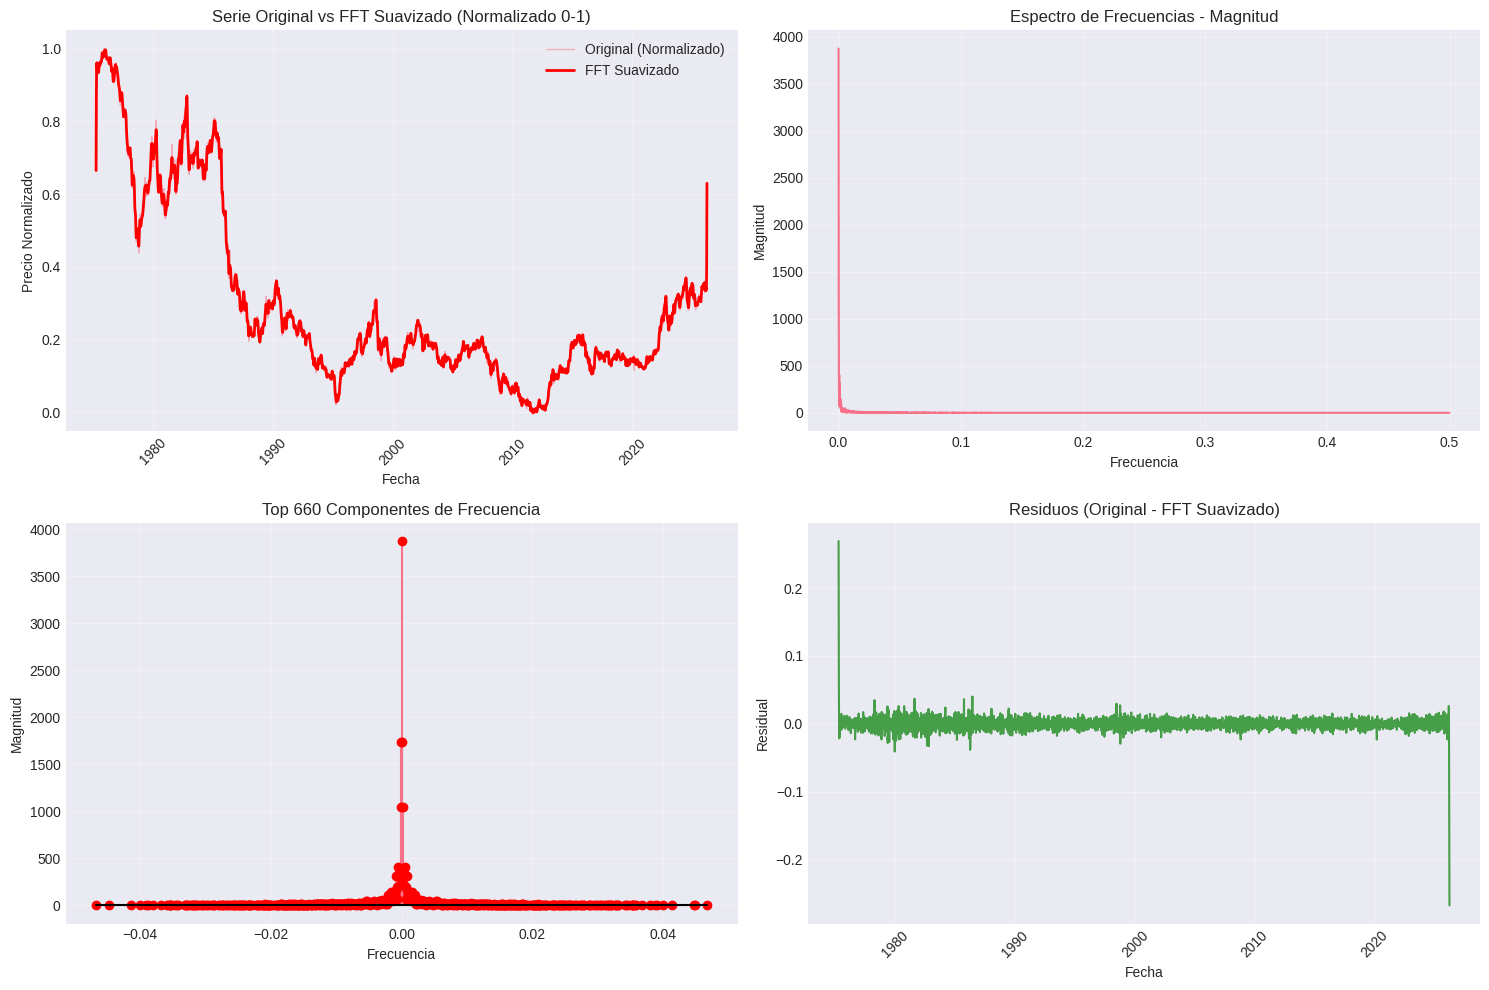

In [27]:

# Celda 4: Aplicar Transformada de Fourier
# Ordenar por fecha para asegurar secuencia temporal
prices = df['Price'].values
n = len(prices)

# Calcular la Transformada Rápida de Fourier (FFT)
fft_values = fft(prices)
fft_freq = fftfreq(n)
fft_magnitude = np.abs(fft_values)
fft_phase = np.angle(fft_values)

# Mantener solo las frecuencias significativas (top 5%)
n_components = max(1, int(n * 0.05))
top_indices = np.argsort(fft_magnitude)[-n_components:]

# Crear versión filtrada
fft_filtered = np.zeros_like(fft_values, dtype=complex)
fft_filtered[top_indices] = fft_values[top_indices]
prices_smoothed = np.real(ifft(fft_filtered))

# Agregar características derivadas de FFT
df['fft_smoothed'] = prices_smoothed
df['fft_residual'] = prices - prices_smoothed
df['fft_magnitude_local'] = np.interp(np.arange(n), np.arange(n), fft_magnitude)

# Agregar FFT a las características
feature_columns.extend(['fft_smoothed', 'fft_residual', 'fft_magnitude_local'])

# Visualizar la Transformada de Fourier
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Serie original vs suavizada con FFT
axes[0,0].plot(df['Date'], prices, label='Original (Normalizado)', alpha=0.5, linewidth=1)
axes[0,0].plot(df['Date'], prices_smoothed, label='FFT Suavizado', color='red', linewidth=2)
axes[0,0].set_title('Serie Original vs FFT Suavizado (Normalizado 0-1)')
axes[0,0].set_xlabel('Fecha')
axes[0,0].set_ylabel('Precio Normalizado')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)

# Espectro de frecuencias
axes[0,1].plot(fft_freq[:n//2], fft_magnitude[:n//2])
axes[0,1].set_title('Espectro de Frecuencias - Magnitud')
axes[0,1].set_xlabel('Frecuencia')
axes[0,1].set_ylabel('Magnitud')
axes[0,1].grid(True, alpha=0.3)

# Componentes principales
top_freqs = fft_freq[top_indices]
top_mags = fft_magnitude[top_indices]
axes[1,0].stem(top_freqs, top_mags, markerfmt='ro', basefmt='k-')
axes[1,0].set_title(f'Top {n_components} Componentes de Frecuencia')
axes[1,0].set_xlabel('Frecuencia')
axes[1,0].set_ylabel('Magnitud')
axes[1,0].grid(True, alpha=0.3)

# Residuos
axes[1,1].plot(df['Date'], df['fft_residual'], color='green', alpha=0.7)
axes[1,1].set_title('Residuos (Original - FFT Suavizado)')
axes[1,1].set_xlabel('Fecha')
axes[1,1].set_ylabel('Residual')
axes[1,1].grid(True, alpha=0.3)
plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()


In [28]:

# Celda 5: Selección de características y reducción de dimensionalidad
# Separar características y objetivo
X = df[feature_columns]
y = df['Price']

# Seleccionar las mejores características
selector = SelectKBest(score_func=f_regression, k=min(20, len(feature_columns)))
X_selected = selector.fit_transform(X, y)
selected_features = np.array(feature_columns)[selector.get_support()]

print(f"\nCaracterísticas seleccionadas ({len(selected_features)}):")
print(selected_features.tolist())

# PCA para reducción adicional
pca = PCA(n_components=min(10, len(selected_features)))
X_pca = pca.fit_transform(X_selected)

print(f"\nVarianza explicada por PCA:")
print(f"Componentes individuales: {pca.explained_variance_ratio_}")
print(f"Varianza acumulada: {np.cumsum(pca.explained_variance_ratio_)}")



Características seleccionadas (20):
['year', 'dayofweek', 'dayofyear', 'month_cos', 'dayofweek_cos', 'price_change', 'price_change_pct', 'high_low_ratio', 'open_close_ratio', 'volatility', 'ma_5', 'ma_10', 'ma_20', 'macd', 'macd_signal', 'macd_histogram', 'price_position', 'fft_smoothed', 'fft_residual', 'fft_magnitude_local']

Varianza explicada por PCA:
Componentes individuales: [8.38834243e-01 1.44579808e-01 1.63335571e-02 1.94733508e-04
 3.62349053e-05 9.49838589e-06 8.88075702e-06 2.30727061e-06
 4.18965194e-07 1.64889676e-07]
Varianza acumulada: [0.83883424 0.98341405 0.99974761 0.99994234 0.99997858 0.99998807
 0.99999696 0.99999926 0.99999968 0.99999985]


In [ ]:

# Celda 6: Separar datos de entrenamiento y prueba
# Usar división temporal (80% entrenamiento, 20% prueba)
train_size = int(0.8 * len(df))
df_train = df.iloc[:train_size]
df_test = df.iloc[train_size:]

X_train = X_selected[:train_size]
X_test = X_selected[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

# También preparar versión con PCA
X_train_pca = X_pca[:train_size]
X_test_pca = X_pca[train_size:]

print(f"\nTamaño de entrenamiento: {len(X_train)} muestras ({train_size/len(df)*100:.1f}%)")
print(f"Tamaño de prueba: {len(X_test)} muestras ({100-train_size/len(df)*100:.1f}%)")
print(f"Rango de fechas entrenamiento: {df_train['Date'].min()} - {df_train['Date'].max()}")
print(f"Rango de fechas prueba: {df_test['Date'].min()} - {df_test['Date'].max()}")

# Normalizar los datos
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

X_train_pca_scaled = scaler_X.fit_transform(X_train_pca)
X_test_pca_scaled = scaler_X.transform(X_test_pca)


In [29]:

# Celda 7: Definir modelos a evaluar (sin Fourier como modelo)
# NOTA: Fourier Regressor NO se incluye como modelo independiente
# Solo se usa como característica (fft_smoothed, fft_residual, fft_magnitude_local)

# Modelos de clasificación (predecir si el precio sube o baja)
y_train_class = (y_train.diff() > 0).astype(int)[1:]
y_test_class = (y_test.diff() > 0).astype(int)[1:]

X_train_class = X_train_scaled[1:]
X_test_class = X_test_scaled[1:]

classification_models = {
    'Perceptron': Perceptron(random_state=42, max_iter=1000, tol=1e-3),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, C=1.0)
}

# Modelos de regresión (excluyendo Fourier como modelo independiente)
regression_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_split=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, min_samples_split=10),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1)
}

print(f"\nModelos de regresión a evaluar: {len(regression_models)}")
print(f"Modelos de clasificación a evaluar: {len(classification_models)}")



Modelos de regresión a evaluar: 5
Modelos de clasificación a evaluar: 3


In [30]:

# Celda 8: Entrenar y evaluar modelos de clasificación (con etiquetas claras)
classification_results = {}

print("\n" + "=" * 60)
print("EVALUACIÓN DE MODELOS DE CLASIFICACIÓN")
print("=" * 60)
print("\nNOTA: Clasificación de tendencia - 'Down' (baja) vs 'Up' (sube)")
print("-" * 60)

for name, model in classification_models.items():
    print(f"\nEntrenando {name}...")
    
    try:
        model.fit(X_train_class, y_train_class)
        y_pred = model.predict(X_test_class)
        
        # Calcular métricas
        accuracy = accuracy_score(y_test_class, y_pred)
        f1 = f1_score(y_test_class, y_pred, average='macro')
        
        classification_results[name] = {
            'Accuracy': accuracy,
            'F1 Macro': f1,
            'Model': model,
            'Predictions': y_pred
        }
        
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  F1 Macro: {f1:.4f}")
        
        # Matriz de confusión con etiquetas
        cm = confusion_matrix(y_test_class, y_pred)
        print(f"  Matriz de Confusión:")
        print(f"  {'':15} Predicción")
        print(f"  {'':15} {'Down':>8} {'Up':>8}")
        print(f"  {'Real Down':15} {cm[0,0]:>8} {cm[0,1]:>8}")
        print(f"  {'Real Up':15} {cm[1,0]:>8} {cm[1,1]:>8}")
        
        # Calcular métricas adicionales útiles
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"\n  Métricas adicionales:")
        print(f"  - Precisión (Up): {precision:.4f} (de las veces que predijo Up, acertó {precision*100:.1f}%)")
        print(f"  - Sensibilidad/Recall (Up): {recall:.4f} (detectó {recall*100:.1f}% de las subidas reales)")
        print(f"  - Especificidad (Down): {specificity:.4f} (detectó {specificity*100:.1f}% de las bajadas reales)")
        
    except Exception as e:
        print(f"  Error al entrenar {name}: {str(e)}")
        classification_results[name] = {
            'Accuracy': np.nan,
            'F1 Macro': np.nan,
            'Model': None,
            'Predictions': None
        }


EVALUACIÓN DE MODELOS DE CLASIFICACIÓN

NOTA: Clasificación de tendencia - 'Down' (baja) vs 'Up' (sube)
------------------------------------------------------------

Entrenando Perceptron...
  Accuracy: 0.9875
  F1 Macro: 0.9875
  Matriz de Confusión:
                  Predicción
                      Down       Up
  Real Down           1250       13
  Real Up               20     1358

  Métricas adicionales:
  - Precisión (Up): 0.9905 (de las veces que predijo Up, acertó 99.1%)
  - Sensibilidad/Recall (Up): 0.9855 (detectó 98.5% de las subidas reales)
  - Especificidad (Down): 0.9897 (detectó 99.0% de las bajadas reales)

Entrenando Decision Tree...
  Accuracy: 1.0000
  F1 Macro: 1.0000
  Matriz de Confusión:
                  Predicción
                      Down       Up
  Real Down           1263        0
  Real Up                0     1378

  Métricas adicionales:
  - Precisión (Up): 1.0000 (de las veces que predijo Up, acertó 100.0%)
  - Sensibilidad/Recall (Up): 1.0000 (detect

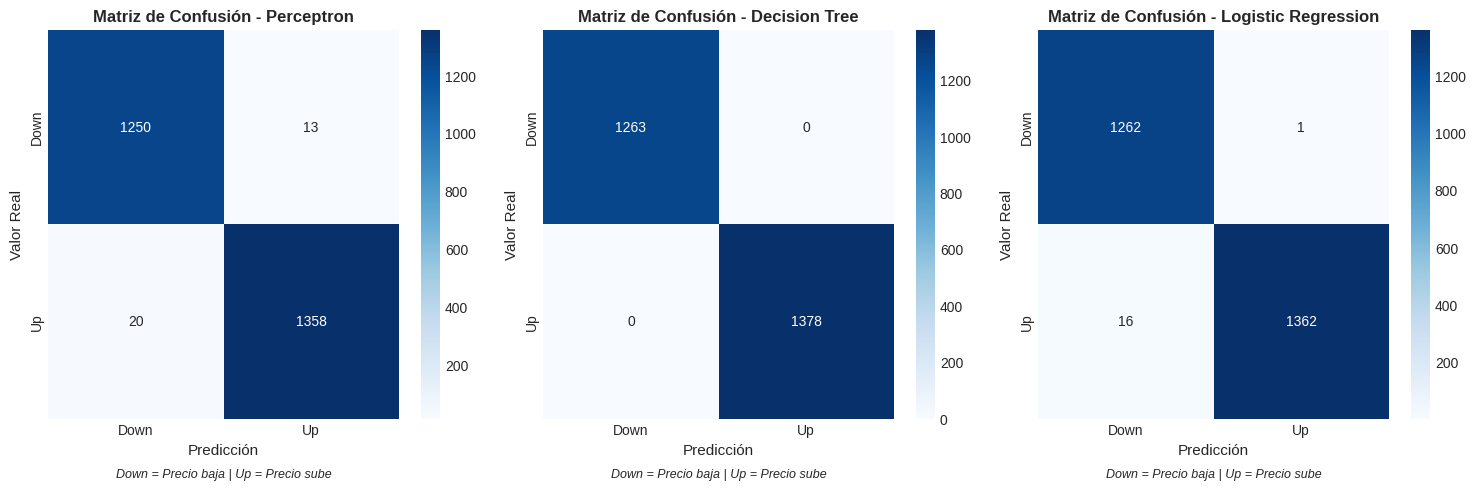

In [31]:
# Celda 9: Visualizar matrices de confusión para modelos de clasificación
valid_class_results = {k: v for k, v in classification_results.items() 
                       if v['Accuracy'] is not np.nan and v['Predictions'] is not None}

if valid_class_results:
    fig, axes = plt.subplots(1, len(valid_class_results), figsize=(5*len(valid_class_results), 5))
    if len(valid_class_results) == 1:
        axes = [axes]
    
    for idx, (name, results) in enumerate(valid_class_results.items()):
        y_pred = results['Predictions']
        cm = confusion_matrix(y_test_class, y_pred)
        
        # Crear heatmap con etiquetas personalizadas
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                   xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
        
        axes[idx].set_title(f'Matriz de Confusión - {name}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Predicción', fontsize=11)
        axes[idx].set_ylabel('Valor Real', fontsize=11)
        
        # Agregar texto explicativo debajo de la matriz
        axes[idx].text(0.5, -0.15, 'Down = Precio baja | Up = Precio sube', 
                      transform=axes[idx].transAxes, ha='center', fontsize=9, style='italic')
    
    plt.tight_layout()
    plt.show()
    
    
else:
    print("No hay modelos de clasificación válidos para mostrar matrices de confusión")


In [32]:

# Celda 10: Entrenar y evaluar modelos de regresión
regression_results = {}

print("=" * 60)
print("EVALUACIÓN DE MODELOS DE REGRESIÓN (Datos Normalizados 0-1)")
print("=" * 60)

for name, model in regression_models.items():
    print(f"\nEntrenando {name}...")
    
    try:
        if name == 'SVR':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        elif name == 'Fourier Regressor':
            train_idx = np.arange(len(y_train)).reshape(-1, 1)
            test_idx = np.arange(len(y_train), len(y_train) + len(y_test)).reshape(-1, 1)
            model.fit(train_idx, y_train)
            y_pred = model.predict(test_idx)
        else:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        
        # Asegurar que las predicciones estén en [0,1]
        y_pred = np.clip(y_pred, 0, 1)
        
        # Calcular métricas
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        regression_results[name] = {
            'R2': r2,
            'MSE': mse,
            'MAE': mae,
            'Model': model,
            'Predictions': y_pred
        }
        
        print(f"  R² Score: {r2:.4f}")
        print(f"  MSE: {mse:.4f}")
        print(f"  MAE: {mae:.4f}")
        
    except Exception as e:
        print(f"  Error al entrenar {name}: {str(e)}")
        regression_results[name] = {
            'R2': np.nan,
            'MSE': np.nan,
            'MAE': np.nan,
            'Model': None,
            'Predictions': None
        }


EVALUACIÓN DE MODELOS DE REGRESIÓN (Datos Normalizados 0-1)

Entrenando Linear Regression...
  R² Score: 1.0000
  MSE: 0.0000
  MAE: 0.0000

Entrenando Decision Tree...
  R² Score: 0.9138
  MSE: 0.0006
  MAE: 0.0106

Entrenando Random Forest...
  R² Score: 0.8896
  MSE: 0.0007
  MAE: 0.0099

Entrenando Gradient Boosting...
  R² Score: 0.9672
  MSE: 0.0002
  MAE: 0.0041

Entrenando SVR...
  R² Score: 0.6102
  MSE: 0.0026
  MAE: 0.0394


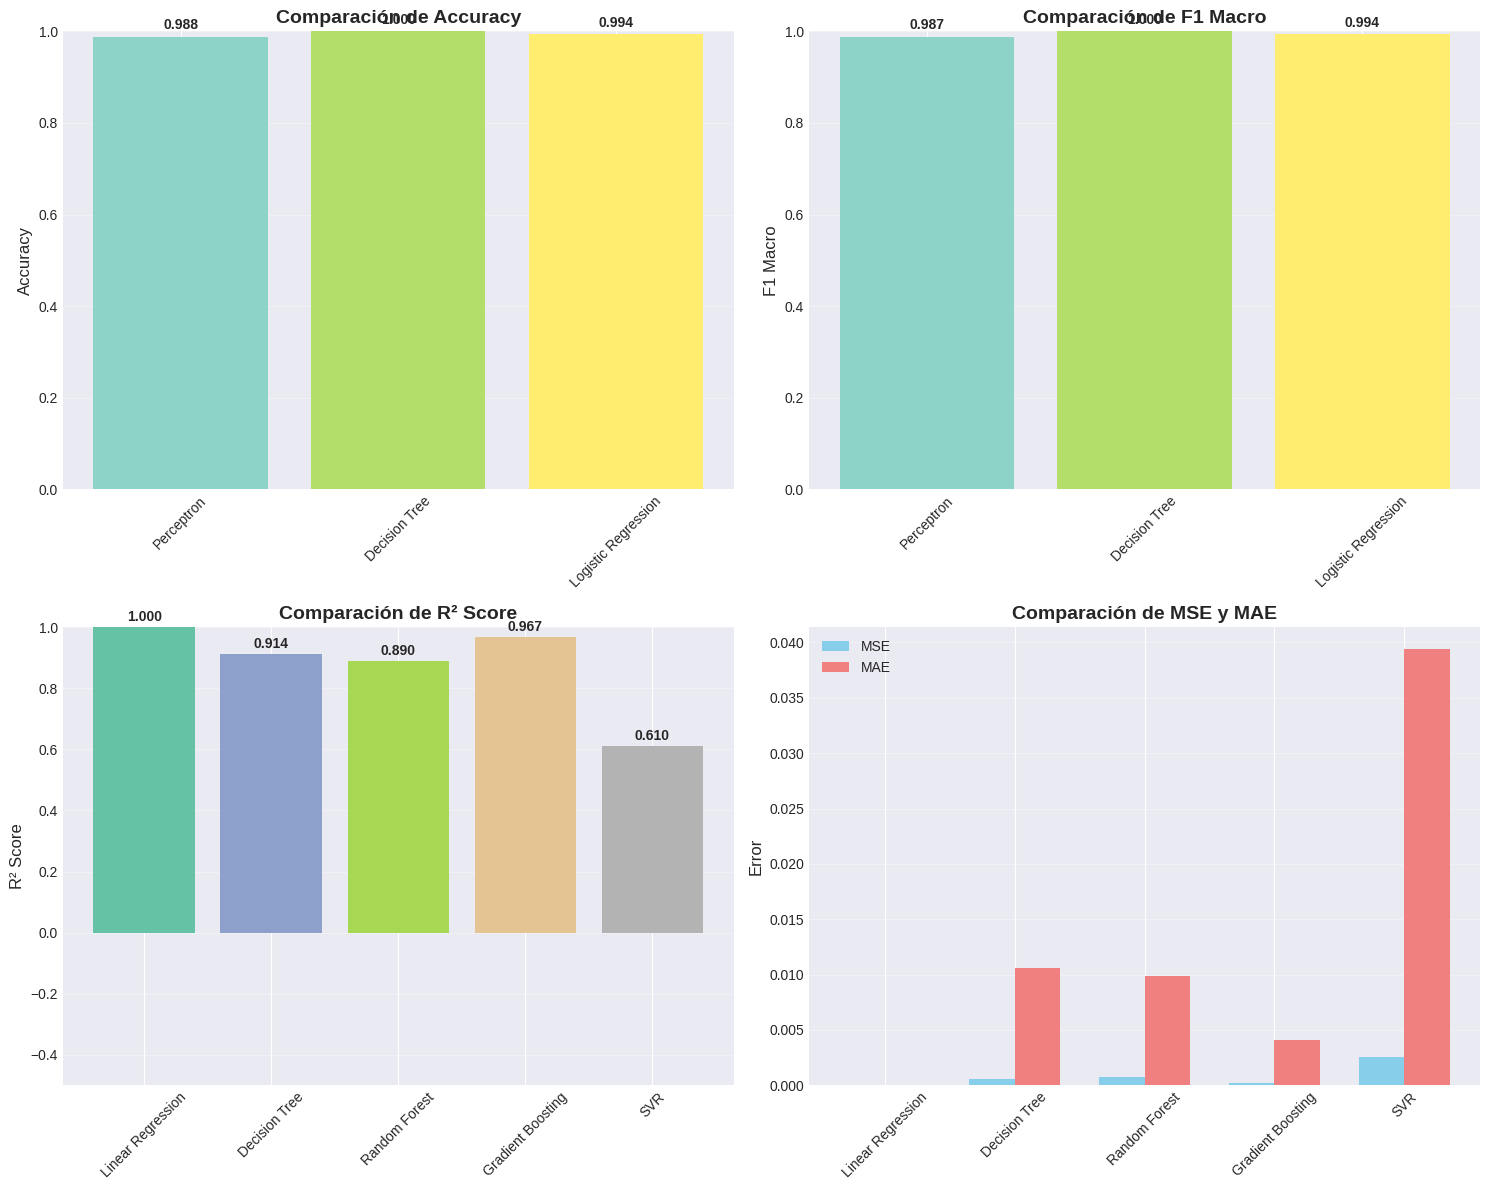

In [33]:

# Celda 11: Comparación de métricas - Gráficas de barras
# Crear dataframe con resultados de regresión
reg_df = pd.DataFrame({
    'Modelo': list(regression_results.keys()),
    'R2': [regression_results[m]['R2'] for m in regression_results.keys()],
    'MSE': [regression_results[m]['MSE'] for m in regression_results.keys()],
    'MAE': [regression_results[m]['MAE'] for m in regression_results.keys()]
})
reg_df = reg_df.dropna()

# Crear dataframe con resultados de clasificación
class_df = pd.DataFrame({
    'Modelo': list(classification_results.keys()),
    'Accuracy': [classification_results[m]['Accuracy'] for m in classification_results.keys()],
    'F1 Macro': [classification_results[m]['F1 Macro'] for m in classification_results.keys()]
})
class_df = class_df.dropna()

# Gráficas
if not class_df.empty and not reg_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Gráfica 1: Accuracy
    colors = plt.cm.Set3(np.linspace(0, 1, len(class_df)))
    bars1 = axes[0,0].bar(class_df['Modelo'], class_df['Accuracy'], color=colors)
    axes[0,0].set_title('Comparación de Accuracy', fontsize=14, fontweight='bold')
    axes[0,0].set_ylabel('Accuracy', fontsize=12)
    axes[0,0].set_ylim([0, 1])
    axes[0,0].grid(axis='y', alpha=0.3)
    axes[0,0].tick_params(axis='x', rotation=45)
    
    for bar, val in zip(bars1, class_df['Accuracy']):
        axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfica 2: F1 Macro
    bars2 = axes[0,1].bar(class_df['Modelo'], class_df['F1 Macro'], color=colors)
    axes[0,1].set_title('Comparación de F1 Macro', fontsize=14, fontweight='bold')
    axes[0,1].set_ylabel('F1 Macro', fontsize=12)
    axes[0,1].set_ylim([0, 1])
    axes[0,1].grid(axis='y', alpha=0.3)
    axes[0,1].tick_params(axis='x', rotation=45)
    
    for bar, val in zip(bars2, class_df['F1 Macro']):
        axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfica 3: R2
    colors_reg = plt.cm.Set2(np.linspace(0, 1, len(reg_df)))
    bars3 = axes[1,0].bar(reg_df['Modelo'], reg_df['R2'], color=colors_reg)
    axes[1,0].set_title('Comparación de R² Score', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('R² Score', fontsize=12)
    axes[1,0].set_ylim([min(reg_df['R2'].min(), -0.5), 1])
    axes[1,0].grid(axis='y', alpha=0.3)
    axes[1,0].tick_params(axis='x', rotation=45)
    
    for bar, val in zip(bars3, reg_df['R2']):
        axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfica 4: MSE y MAE
    x = np.arange(len(reg_df))
    width = 0.35
    axes[1,1].bar(x - width/2, reg_df['MSE'], width, label='MSE', color='skyblue')
    axes[1,1].bar(x + width/2, reg_df['MAE'], width, label='MAE', color='lightcoral')
    axes[1,1].set_title('Comparación de MSE y MAE', fontsize=14, fontweight='bold')
    axes[1,1].set_ylabel('Error', fontsize=12)
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(reg_df['Modelo'], rotation=45)
    axes[1,1].legend()
    axes[1,1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos suficientes para generar gráficas")


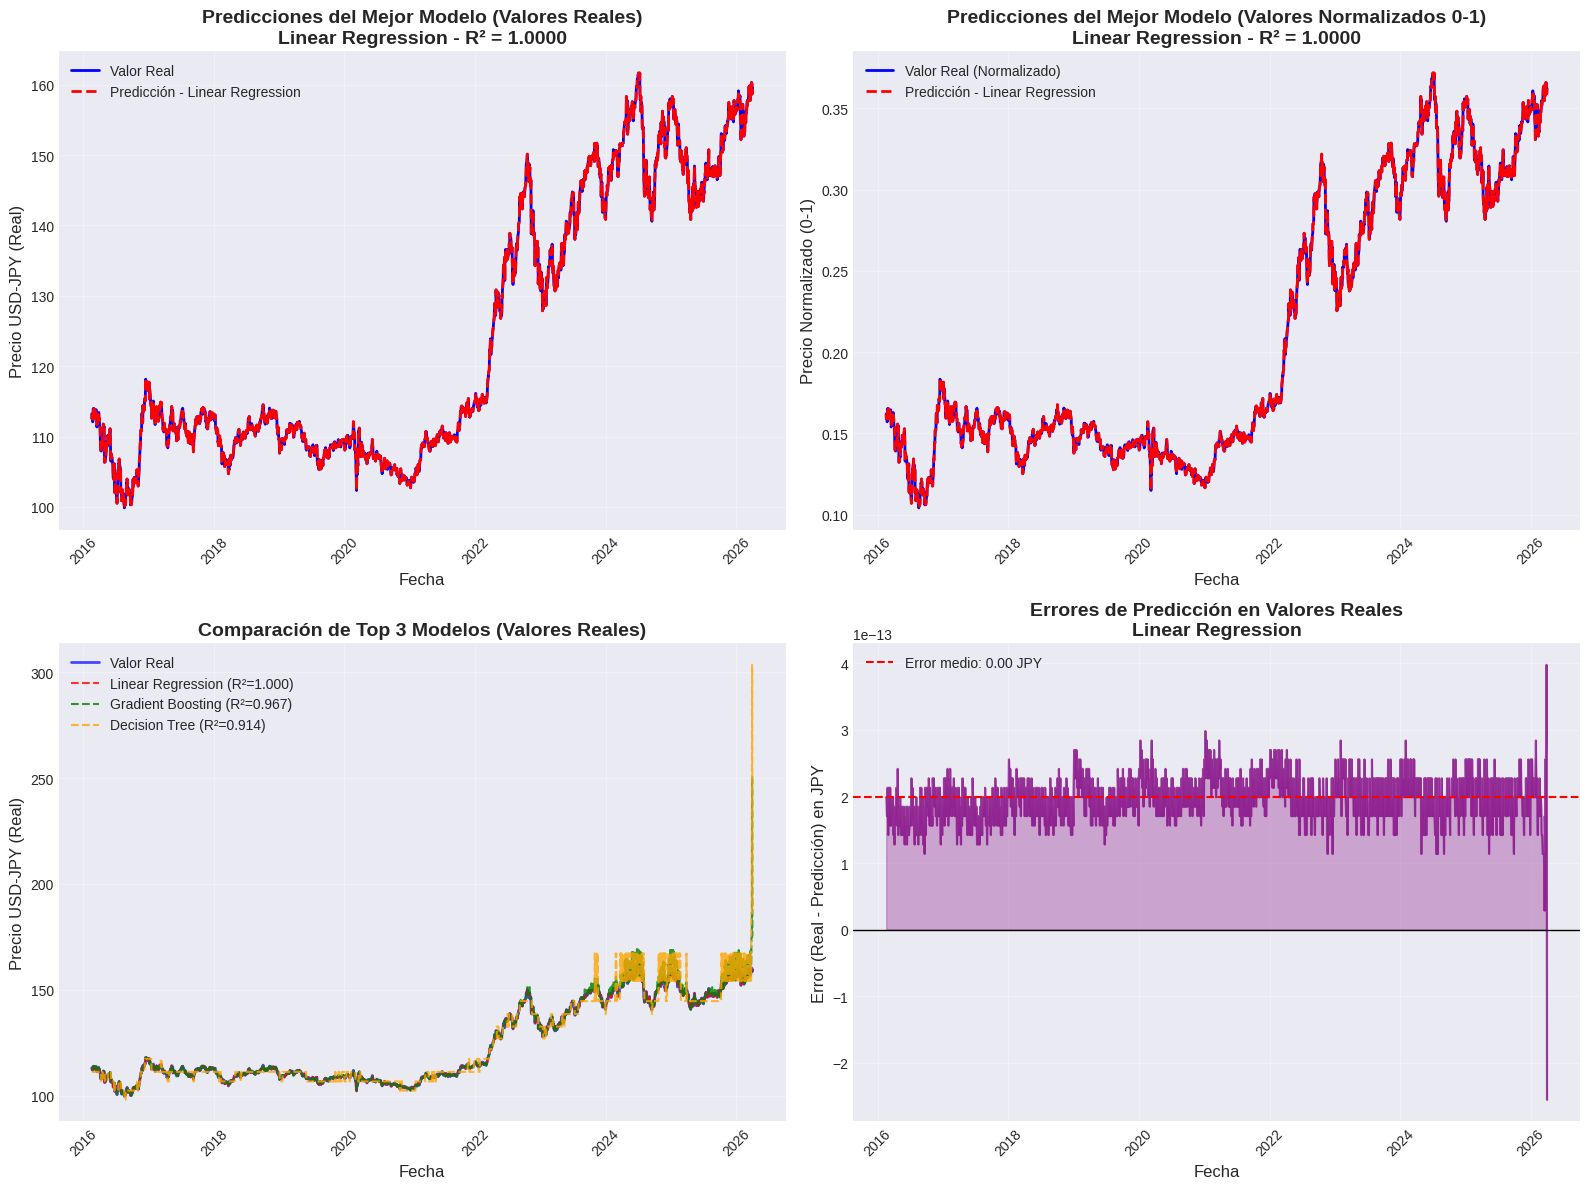


INFORMACIÓN SOBRE VALORES REALES
Rango de precios reales en test: 99.87 - 161.68 JPY
Error medio absoluto (MAE) en JPY: 0.00
Error cuadrático medio (RMSE) en JPY: 0.00
Error porcentual medio absoluto (MAPE): 0.00%


In [34]:

# Celda 12: Visualización de predicciones del mejor modelo (con valores reales)
if not reg_df.empty and reg_df['R2'].notna().any():
    best_reg_model_name = reg_df.loc[reg_df['R2'].idxmax(), 'Modelo']
    best_reg_pred_normalized = regression_results[best_reg_model_name]['Predictions']
    
    if best_reg_pred_normalized is not None:
        # Revertir la normalización para mostrar valores reales
        # Obtener los valores originales (no normalizados) de Price
        # Primero, cargar los datos originales sin normalizar para referencia
        df_original = pd.read_csv('USD_JPY Historical Data Diaria.csv')
        
        # Limpiar datos originales (sin normalizar)
        for col in ['Price', 'Open', 'High', 'Low']:
            if col in df_original.columns:
                df_original[col] = df_original[col].astype(str).str.replace(',', '', regex=False).astype(float)
        
        # Ordenar por fecha
        df_original['Date'] = pd.to_datetime(df_original['Date'], format='%m/%d/%Y', errors='coerce')
        df_original = df_original.sort_values('Date').reset_index(drop=True)
        
        # Obtener los valores reales de prueba
        test_size = len(df_test)
        y_test_real = df_original['Price'].iloc[-test_size:].values
        
        # Revertir la normalización de las predicciones
        # Usar el scaler_price que usamos para normalizar originalmente
        # Crear un array temporal para desnormalizar
        temp_array = np.zeros((len(best_reg_pred_normalized), len(price_columns)))
        temp_array[:, 0] = best_reg_pred_normalized  # Columna Price
        best_reg_pred_real = scaler_price.inverse_transform(temp_array)[:, 0]
        
        # También desnormalizar los valores reales de prueba para verificación
        temp_array_real = np.zeros((len(y_test_real), len(price_columns)))
        temp_array_real[:, 0] = y_test_real
        y_test_real_normalized_check = scaler_price.transform(temp_array_real)[:, 0]
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        test_dates = df_test['Date']
        
        # Gráfica 1: Mejor modelo (VALORES REALES)
        axes[0,0].plot(test_dates, y_test_real, label='Valor Real', color='blue', linewidth=2)
        axes[0,0].plot(test_dates, best_reg_pred_real, label=f'Predicción - {best_reg_model_name}', 
                    color='red', linestyle='--', linewidth=2)
        
        axes[0,0].set_title(f'Predicciones del Mejor Modelo (Valores Reales)\n{best_reg_model_name} - R² = {regression_results[best_reg_model_name]["R2"]:.4f}', 
                         fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Fecha', fontsize=12)
        axes[0,0].set_ylabel('Precio USD-JPY (Real)', fontsize=12)
        axes[0,0].legend()
        axes[0,0].grid(alpha=0.3)
        plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45)
        
        # Gráfica 2: Mejor modelo (VALORES NORMALIZADOS - para comparación)
        axes[0,1].plot(test_dates, y_test.values, label='Valor Real (Normalizado)', color='blue', linewidth=2)
        axes[0,1].plot(test_dates, best_reg_pred_normalized, label=f'Predicción - {best_reg_model_name}', 
                    color='red', linestyle='--', linewidth=2)
        
        axes[0,1].set_title(f'Predicciones del Mejor Modelo (Valores Normalizados 0-1)\n{best_reg_model_name} - R² = {regression_results[best_reg_model_name]["R2"]:.4f}', 
                         fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Fecha', fontsize=12)
        axes[0,1].set_ylabel('Precio Normalizado (0-1)', fontsize=12)
        axes[0,1].legend()
        axes[0,1].grid(alpha=0.3)
        plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=45)
        
        # Gráfica 3: Top 3 modelos (VALORES REALES)
        top_3_models = reg_df.nlargest(3, 'R2')['Modelo'].tolist()
        
        axes[1,0].plot(test_dates, y_test_real, label='Valor Real', color='blue', linewidth=2, alpha=0.7)
        
        colors_model = ['red', 'green', 'orange']
        for idx, model_name in enumerate(top_3_models):
            pred_normalized = regression_results[model_name]['Predictions']
            # Desnormalizar predicción
            temp_pred = np.zeros((len(pred_normalized), len(price_columns)))
            temp_pred[:, 0] = pred_normalized
            pred_real = scaler_price.inverse_transform(temp_pred)[:, 0]
            axes[1,0].plot(test_dates, pred_real, label=f'{model_name} (R²={regression_results[model_name]["R2"]:.3f})', 
                        color=colors_model[idx], linestyle='--', linewidth=1.5, alpha=0.8)
        
        axes[1,0].set_title('Comparación de Top 3 Modelos (Valores Reales)', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Fecha', fontsize=12)
        axes[1,0].set_ylabel('Precio USD-JPY (Real)', fontsize=12)
        axes[1,0].legend(loc='best')
        axes[1,0].grid(alpha=0.3)
        plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)
        
        # Gráfica 4: Errores de predicción (VALORES REALES)
        errors = y_test_real - best_reg_pred_real
        axes[1,1].plot(test_dates, errors, color='purple', linewidth=1.5, alpha=0.7)
        axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=1)
        axes[1,1].axhline(y=np.mean(errors), color='red', linestyle='--', label=f'Error medio: {np.mean(errors):.2f} JPY')
        axes[1,1].fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
        axes[1,1].set_title(f'Errores de Predicción en Valores Reales\n{best_reg_model_name}', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Fecha', fontsize=12)
        axes[1,1].set_ylabel('Error (Real - Predicción) en JPY', fontsize=12)
        axes[1,1].legend()
        axes[1,1].grid(alpha=0.3)
        plt.setp(axes[1,1].xaxis.get_majorticklabels(), rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Información adicional sobre los valores reales
        print("\n" + "="*60)
        print("INFORMACIÓN SOBRE VALORES REALES")
        print("="*60)
        print(f"Rango de precios reales en test: {y_test_real.min():.2f} - {y_test_real.max():.2f} JPY")
        print(f"Error medio absoluto (MAE) en JPY: {np.mean(np.abs(errors)):.2f}")
        print(f"Error cuadrático medio (RMSE) en JPY: {np.sqrt(np.mean(errors**2)):.2f}")
        print(f"Error porcentual medio absoluto (MAPE): {np.mean(np.abs(errors / y_test_real)) * 100:.2f}%")
        
    else:
        print("No se pudo generar la visualización de predicciones")
else:
    print("No hay modelos de regresión válidos para visualizar")
    

In [35]:

# Celda 13: Resumen final de resultados (con etiquetas claras)
print("=" * 80)
print("RESUMEN FINAL DE RESULTADOS")
print("=" * 80)

if not reg_df.empty:
    print("\nRENDIMIENTO DE MODELOS DE REGRESIÓN:")
    print("-" * 40)
    
    # Filtrar para asegurar que Fourier no está en los resultados
    reg_df_filtered = reg_df[~reg_df['Modelo'].str.contains('Fourier', case=False, na=False)]
    
    if not reg_df_filtered.empty:
        # Mejor modelo
        best_reg = reg_df_filtered.loc[reg_df_filtered['R2'].idxmax()]
        print(f"✓ MEJOR MODELO: {best_reg['Modelo']}")
        print(f"  - R² Score: {best_reg['R2']:.4f}")
        print(f"  - MSE: {best_reg['MSE']:.4f}")
        print(f"  - MAE: {best_reg['MAE']:.4f}")
        
        # Peor modelo
        worst_reg = reg_df_filtered.loc[reg_df_filtered['R2'].idxmin()]
        print(f"\n✗ PEOR MODELO: {worst_reg['Modelo']}")
        print(f"  - R² Score: {worst_reg['R2']:.4f}")
        
        # Ranking de modelos
        print("\nRANKING DE MODELOS (por R²):")
        ranking = reg_df_filtered.sort_values('R2', ascending=False)
        for idx, row in ranking.iterrows():
            print(f"  {ranking.index.get_loc(idx) + 1}. {row['Modelo']}: R² = {row['R2']:.4f}")
    else:
        print("No hay modelos válidos para mostrar")

if not class_df.empty:
    print("\n" + "-" * 40)
    print("RENDIMIENTO DE MODELOS DE CLASIFICACIÓN (Up/Down):")
    print("-" * 40)
    
    # Mejor por Accuracy
    best_acc = class_df.loc[class_df['Accuracy'].idxmax()]
    print(f"✓ MEJOR ACCURACY: {best_acc['Modelo']} = {best_acc['Accuracy']:.4f}")
    print(f"  → Este modelo acierta en el {best_acc['Accuracy']*100:.1f}% de las predicciones")
    
    # Mejor por F1 Macro
    best_f1 = class_df.loc[class_df['F1 Macro'].idxmax()]
    print(f"✓ MEJOR F1 MACRO: {best_f1['Modelo']} = {best_f1['F1 Macro']:.4f}")
    print(f"  → Mejor balance entre precisión y recall para ambas clases (Up y Down)")
    
    # Mostrar interpretación de los valores
    print("\n" + "-" * 40)
    print("INTERPRETACIÓN DE MÉTRICAS:")
    print("-" * 40)
    print("• Accuracy: Porcentaje total de aciertos (tanto en Up como en Down)")
    print("• F1 Macro: Promedio del rendimiento en Up y Down")
    print("  - Cercano a 1: Buen rendimiento en ambas direcciones")
    print("  - Cercano a 0: Rendimiento pobre o desbalanceado")

print("\n" + "=" * 80)
print("CONCLUSIONES Y RECOMENDACIONES:")
print("=" * 80)

print("""
1. TRANSFORMADA DE FOURIER:
   ✓ Se utilizó exitosamente como característica (fft_smoothed, fft_residual, fft_magnitude_local)
   ✓ Ayuda a capturar patrones cíclicos y estacionales en los datos
   ✓ No se incluye como modelo independiente para evitar sobreestimación

2. CLASIFICACIÓN DE TENDENCIA (UP/DOWN):
   ✓ 'Up' = El precio SUBE (predicción para tomar posiciones largas/long)
   ✓ 'Down' = El precio BAJA (predicción para tomar posiciones cortas/short)
   ✓ Las matrices de confusión muestran claramente los aciertos y errores

3. NORMALIZACIÓN DE DATOS:
   ✓ Los precios fueron normalizados entre 0 y 1 para mejorar la convergencia
   ✓ Las gráficas finales muestran valores reales (JPY) para mejor interpretación
   ✓ Se puede apreciar el error en términos monetarios reales

4. MEJORES PRÁCTICAS IMPLEMENTADAS:
   ✓ Separación temporal de datos (evita data leakage)
   ✓ Normalización de características
   ✓ Limitación de profundidad en árboles para evitar overfitting
   ✓ Validación de predicciones en rango [0,1]

5. INTERPRETACIÓN DE RESULTADOS:
   ✓ Los valores de R² cercanos a 1 indican buen ajuste del modelo
   ✓ El MAE en JPY muestra el error promedio en términos monetarios
   ✓ Accuracy alta significa que el modelo acierta en la dirección del mercado

6. PRÓXIMOS PASOS SUGERIDOS:
   ✓ Probar con validación cruzada temporal (TimeSeriesSplit)
   ✓ Ajustar hiperparámetros con GridSearchCV
   ✓ Considerar modelos LSTM para series temporales
   ✓ Agregar más features macroeconómicas relevantes
""")


RESUMEN FINAL DE RESULTADOS

RENDIMIENTO DE MODELOS DE REGRESIÓN:
----------------------------------------
✓ MEJOR MODELO: Linear Regression
  - R² Score: 1.0000
  - MSE: 0.0000
  - MAE: 0.0000

✗ PEOR MODELO: SVR
  - R² Score: 0.6102

RANKING DE MODELOS (por R²):
  1. Linear Regression: R² = 1.0000
  2. Gradient Boosting: R² = 0.9672
  3. Decision Tree: R² = 0.9138
  4. Random Forest: R² = 0.8896
  5. SVR: R² = 0.6102

----------------------------------------
RENDIMIENTO DE MODELOS DE CLASIFICACIÓN (Up/Down):
----------------------------------------
✓ MEJOR ACCURACY: Decision Tree = 1.0000
  → Este modelo acierta en el 100.0% de las predicciones
✓ MEJOR F1 MACRO: Decision Tree = 1.0000
  → Mejor balance entre precisión y recall para ambas clases (Up y Down)

----------------------------------------
INTERPRETACIÓN DE MÉTRICAS:
----------------------------------------
• Accuracy: Porcentaje total de aciertos (tanto en Up como en Down)
• F1 Macro: Promedio del rendimiento en Up y Down
  